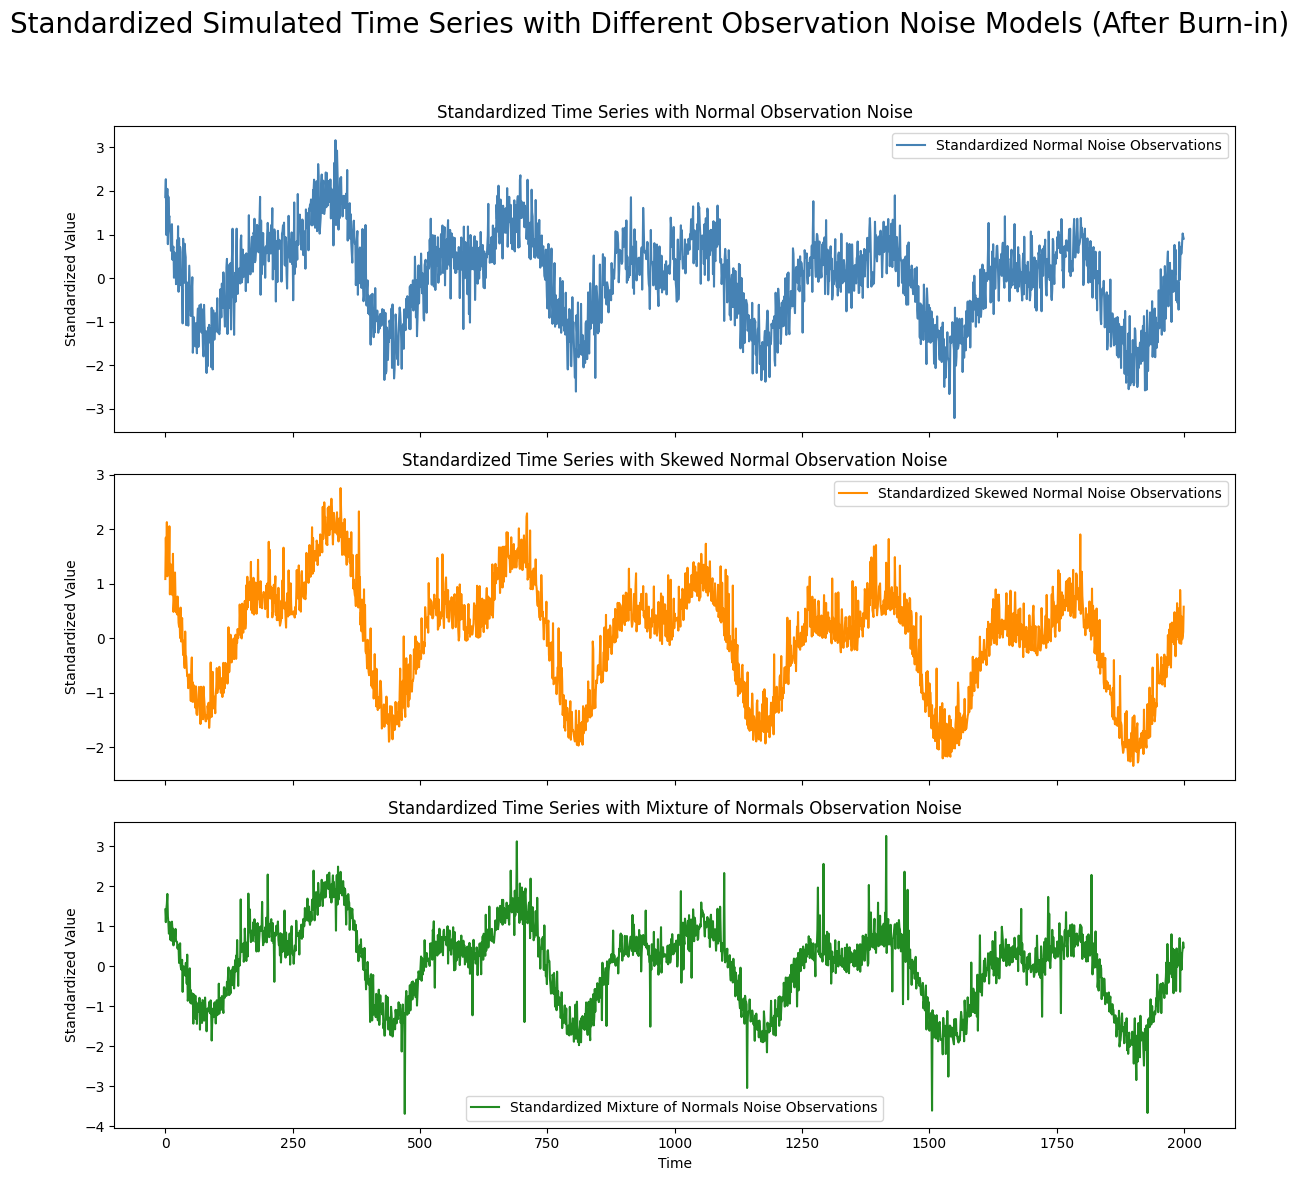

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

# Set random seed for reproducibility
np.random.seed(66)

# Step 1: Initialize Parameters
burn_in = 20000
T = 2000 + burn_in  # Total number of time steps (including burn-in)
final_steps = T - burn_in  # Number of steps to keep after burn-in

f_yearly = 1/365  # Frequency for yearly periodicity
f_semi = 2/365    # Frequency for semi-annual periodicity

# Initial state vector with amplified periodic components [cubic trend, quadratic trend, linear trend, yearly cos, yearly sin, semi-annual cos, semi-annual sin]
x0 = np.array([0, 0, 0, 0, 0, 0, 0])  # Amplified initial state for periodic components

# State transition matrix F (incorporates cubic, quadratic, linear, yearly and semi-annual periodicities)
F = np.array([
    [1, 1, 0, 0, 0, 0, 0],  # Cubic trend evolves to quadratic + cubic trend
    [0, 1, 1, 0, 0, 0, 0],  # Quadratic trend evolves to linear + quadratic trend
    [0, 0, 1, 0, 0, 0, 0],  # Linear trend stays the same
    [0, 0, 0, np.cos(2 * np.pi * f_yearly), -np.sin(2 * np.pi * f_yearly), 0, 0],  # Yearly periodicity (cos)
    [0, 0, 0, np.sin(2 * np.pi * f_yearly), np.cos(2 * np.pi * f_yearly), 0, 0],   # Yearly periodicity (sin)
    [0, 0, 0, 0, 0, np.cos(2 * np.pi * f_semi), -np.sin(2 * np.pi * f_semi)],      # Semi-annual periodicity (cos)
    [0, 0, 0, 0, 0, np.sin(2 * np.pi * f_semi), np.cos(2 * np.pi * f_semi)]        # Semi-annual periodicity (sin)
])

# Observation matrix H (combines cubic, quadratic, linear, and amplified periodicities)
H = np.array([1, 0.5, 0.5, 40, 0, 30, 0])  # Increased weight for periodic components and the new cubic trend

# Dynamics noise covariance matrix Q
a = 0.0005
b = 1
Q = b * np.eye(7)  # Small variance for dynamics noise
Q[0, 0] = a
Q[1, 1] = a**2
Q[2, 2] = a**2.5

# Observation noise parameters
sigma_normal = 4000  # Standard deviation for normal noise
xi = 0  # Location parameter for skewed normal
omega = sigma_normal  # Scale parameter for skewed normal
alpha = 10  # Skewness parameter
p = 0.9  # Probability of selecting the first normal distribution in the mixture
mu1, sigma1 = 0, sigma_normal/2  # Mean and standard deviation for first normal in mixture
mu2, sigma2 = 0, 2*sigma_normal  # Mean and standard deviation for second normal in mixture

# Step 2: Simulate the State Sequence (including burn-in period)
# Initialize state sequence with initial state
states = [x0]

for t in range(1, T):
    # Generate dynamics noise vt ~ N(0, Q)
    vt = np.random.multivariate_normal(np.zeros(7), Q)
    # Evolve state using state transition equation
    xt = F @ states[-1] + vt
    states.append(xt)

# Convert state sequence to a numpy array for easier indexing
states = np.array(states)

# Remove the burn-in period from the state sequence
states = states[burn_in:]

# Step 3: Generate Observations for Each Noise Model (after burn-in period)
def generate_observations(noise_type):
    """
    Generate observations based on specified observation noise type after burn-in period.
    """
    observations = []

    for t in range(final_steps):  # Generate observations only for the final steps after burn-in
        # Current state
        xt = states[t]
        
        # Observation equation: y_t = H * x_t + w_t
        if noise_type == 'normal':
            # Normal observation noise
            wt = np.random.normal(0, sigma_normal)
        elif noise_type == 'skewed_normal':
            # Skewed normal observation noise
            wt = skewnorm.rvs(alpha, loc=xi, scale=omega)
        elif noise_type == 'mixture_normal':
            # Mixture of two normal distributions: choose one distribution based on probability p
            if np.random.rand() < p:
                wt = np.random.normal(mu1, sigma1)  # Select from first normal distribution
            else:
                wt = np.random.normal(mu2, sigma2)  # Select from second normal distribution
        else:
            raise ValueError("Invalid noise type. Choose 'normal', 'skewed_normal', or 'mixture_normal'.")
        
        # Observation
        yt = H @ xt + wt
        observations.append(yt)
    
    return np.array(observations)

# Generate observations for each noise type (after burn-in period)
normal_observations = generate_observations('normal')
skewed_observations = generate_observations('skewed_normal')
mixture_observations = generate_observations('mixture_normal')

# Standardize observations
def standardize(data):
    return (data - np.mean(data)) / np.std(data)

# Standardize the generated observations
normal_observations = standardize(normal_observations)
skewed_observations = standardize(skewed_observations)
mixture_observations = standardize(mixture_observations)

# Step 4: Visualize the Results - Standardized Time Series
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot standardized observations for each noise type
axes[0].plot(range(final_steps), normal_observations, label='Standardized Normal Noise Observations', color='steelblue')
axes[0].set_title('Standardized Time Series with Normal Observation Noise')
axes[0].set_ylabel('Standardized Value')
axes[0].legend()

axes[1].plot(range(final_steps), skewed_observations, label='Standardized Skewed Normal Noise Observations', color='darkorange')
axes[1].set_title('Standardized Time Series with Skewed Normal Observation Noise')
axes[1].set_ylabel('Standardized Value')
axes[1].legend()

axes[2].plot(range(final_steps), mixture_observations, label='Standardized Mixture of Normals Noise Observations', color='forestgreen')
axes[2].set_title('Standardized Time Series with Mixture of Normals Observation Noise')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Standardized Value')
axes[2].legend()

# Adjust layout and display plots
plt.suptitle('Standardized Simulated Time Series with Different Observation Noise Models (After Burn-in)', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


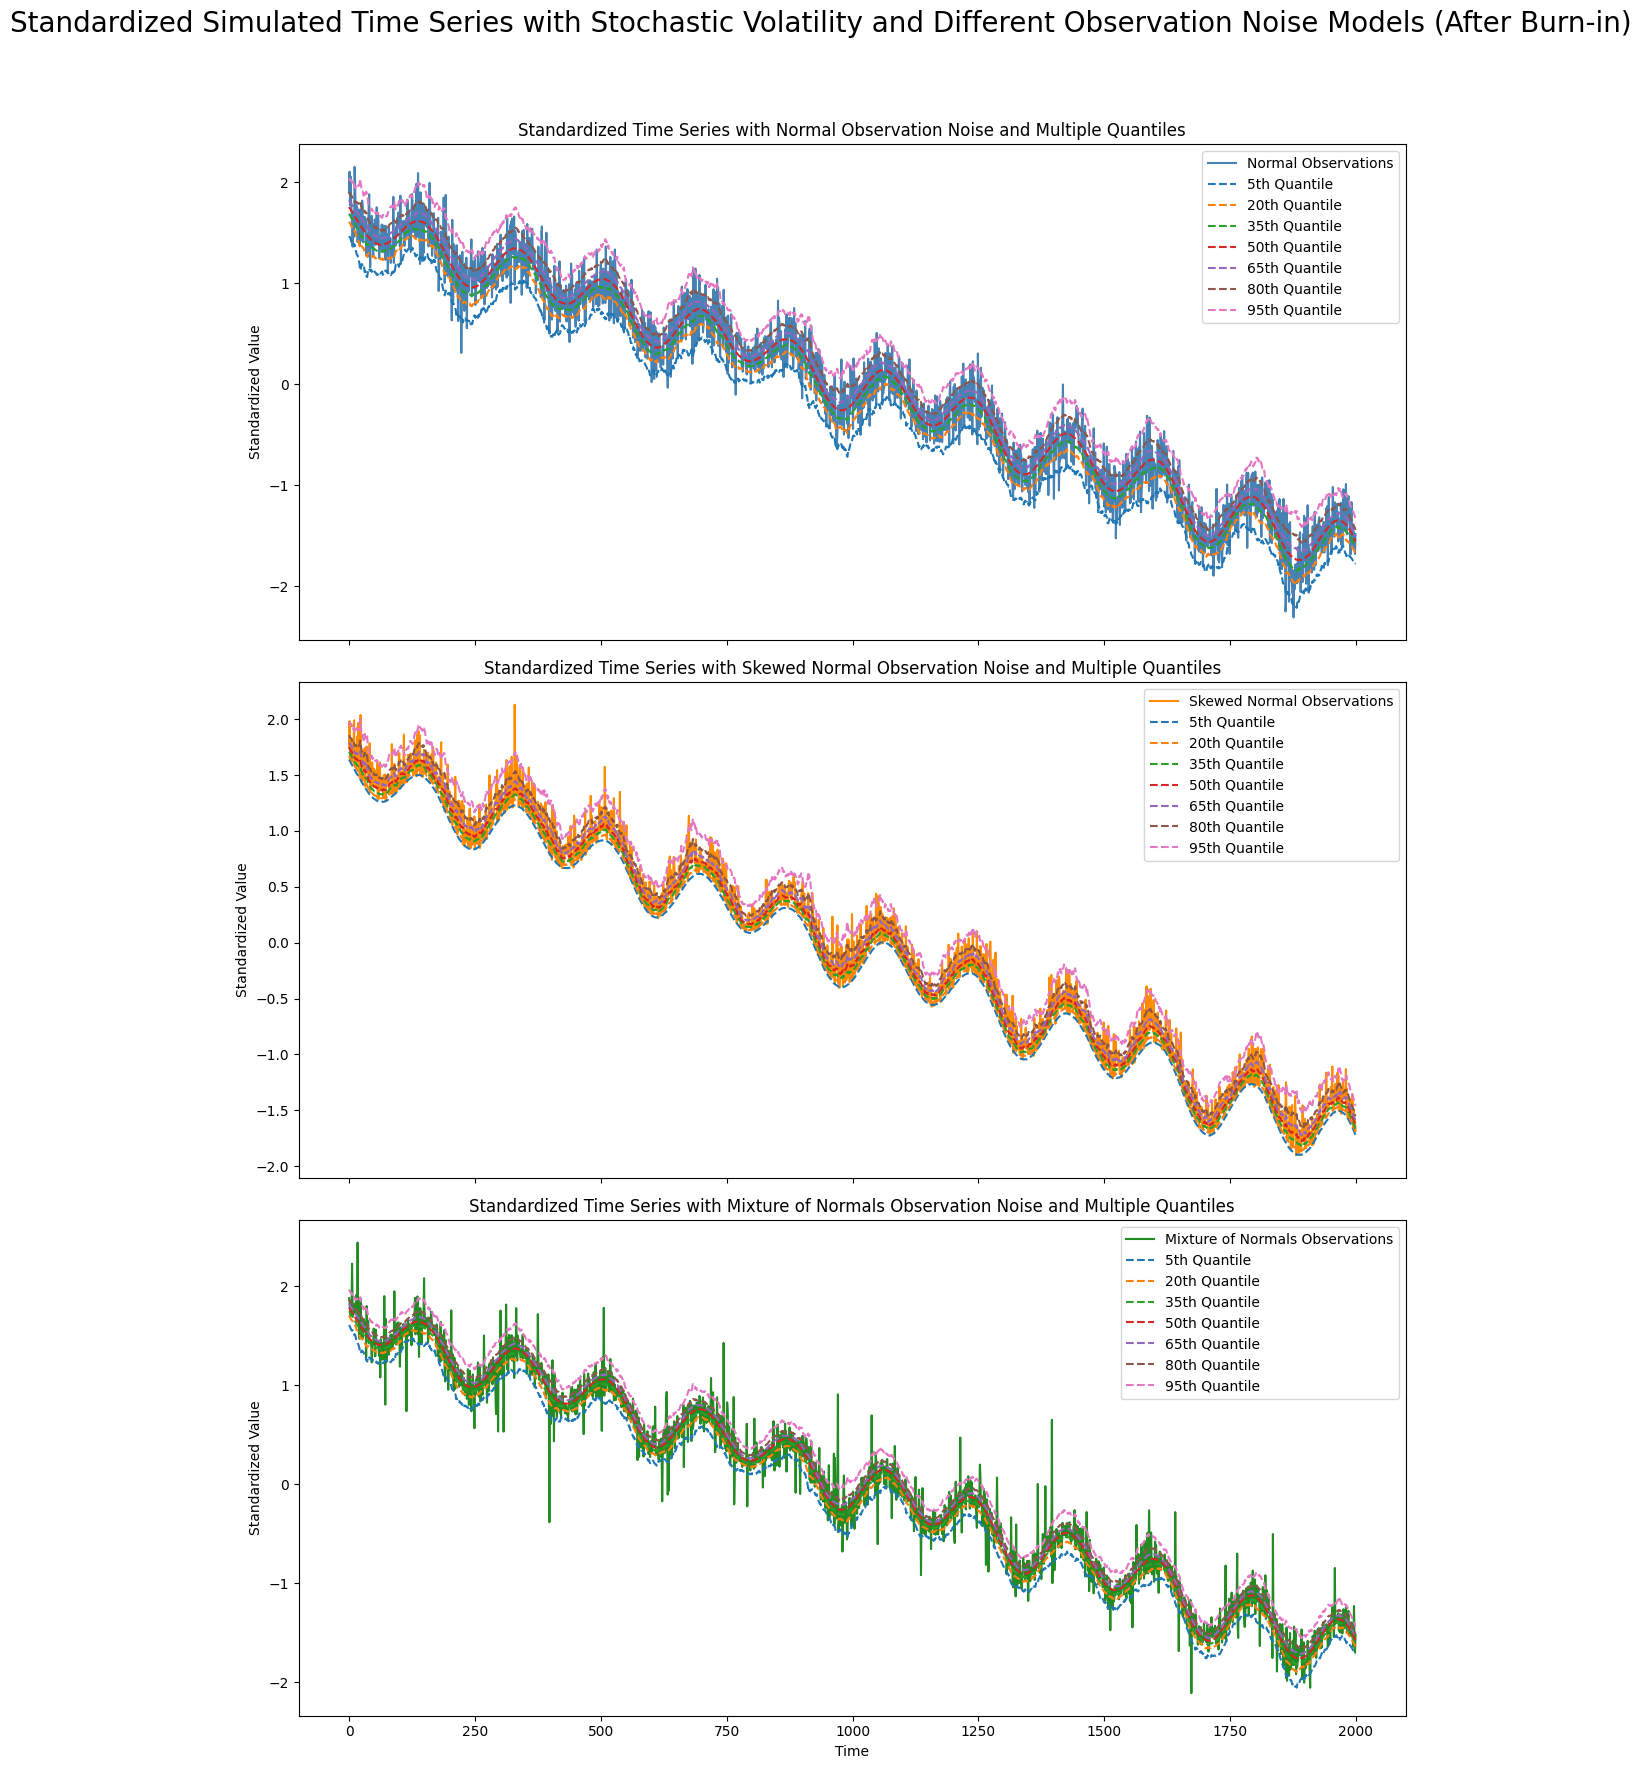

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
from joblib import Parallel, delayed

# Set random seed for reproducibility
np.random.seed(66)

# Step 1: Initialize Parameters
burn_in = 20000
T = 2000 + burn_in  # Total number of time steps (including burn-in)
final_steps = T - burn_in  # Number of steps to keep after burn-in
num_mc_samples = 50000  # Number of Monte Carlo samples for quantile approximation
n_jobs = -1  # Use all available CPU cores for parallel processing

f_yearly = 1/365  # Frequency for yearly periodicity
f_semi = 2/365    # Frequency for semi-annual periodicity

# Parameters for stochastic volatility
phi = 0.95        # Autoregressive coefficient for the log-volatility process (controls persistence)
sigma_eta = 0.1   # Standard deviation of the log-volatility process (controls variability)

# Initial state vector with amplified periodic components and a new volatility state
x0 = np.array([0, 0, 0, 0, 0, 0, 0, 0])  # Includes the initial log-volatility state

# State transition matrix F (includes the AR(1) process for volatility)
F = np.array([
    [1, 1, 0, 0, 0, 0, 0, 0],  # Cubic trend evolves to quadratic + cubic trend
    [0, 1, 1, 0, 0, 0, 0, 0],  # Quadratic trend evolves to linear + quadratic trend
    [0, 0, 1, 0, 0, 0, 0, 0],  # Linear trend stays the same
    [0, 0, 0, np.cos(2 * np.pi * f_yearly), -np.sin(2 * np.pi * f_yearly), 0, 0, 0],  # Yearly periodicity (cos)
    [0, 0, 0, np.sin(2 * np.pi * f_yearly), np.cos(2 * np.pi * f_yearly), 0, 0, 0],   # Yearly periodicity (sin)
    [0, 0, 0, 0, 0, np.cos(2 * np.pi * f_semi), -np.sin(2 * np.pi * f_semi), 0],      # Semi-annual periodicity (cos)
    [0, 0, 0, 0, 0, np.sin(2 * np.pi * f_semi), np.cos(2 * np.pi * f_semi), 0],       # Semi-annual periodicity (sin)
    [0, 0, 0, 0, 0, 0, 0, phi]  # AR(1) process for log-volatility
])

# Observation matrix H (weights for the periodic components)
H = np.array([1, 0.5, 0.5, 30, 0, 40, 0, 0])  # Excludes the volatility term in the observation

# Dynamics noise covariance matrix Q
a = 0.0005  # Scale for the state noise variance
Q = np.eye(8)  # Dynamics noise covariance matrix including volatility process
Q[0, 0] = a
Q[1, 1] = a**2
Q[2, 2] = a**2.5
Q[-1, -1] = sigma_eta**2  # Variance for the log-volatility process

# Observation noise parameters
sigma_normal = 10000  # Initial standard deviation for normal noise
xi = 0  # Location parameter for skewed normal
omega = sigma_normal  # Scale parameter for skewed normal
alpha = 20  # Skewness parameter
p = 0.9  # Probability of selecting the first normal distribution in the mixture
mu1, sigma1 = 0, sigma_normal/2  # Initial mean and standard deviation for first normal in mixture
mu2, sigma2 = 0, 2*sigma_normal  # Initial mean and standard deviation for second normal in mixture

# Step 2: Simulate the State Sequence (including burn-in period)
states = [x0]

for t in range(1, T):
    # Generate dynamics noise vt ~ N(0, Q)
    vt = np.random.multivariate_normal(np.zeros(8), Q)
    # Evolve state using state transition equation
    xt = F @ states[-1] + vt
    states.append(xt)

# Convert state sequence to a numpy array for easier indexing
states = np.array(states)

# Remove the burn-in period from the state sequence
states = states[burn_in:]

# Extract the volatility component (log-volatility)
log_volatility = states[:, -1]  # Extract the last column which is log-volatility
volatility = np.exp(log_volatility / 2)  # Standard deviation = exp(log_vol / 2)

# Step 3: Generate Observations with Stochastic Volatility
def generate_observations_stochastic_volatility(states, noise_type):
    """
    Generate observations based on the specified observation noise type using stochastic volatility.
    """
    T = states.shape[0]
    
    # Scale the observation noise using stochastic volatility
    sigma_dynamic = sigma_normal * volatility  # Scale by dynamic volatility for normal distribution
    sigma1_dynamic = sigma1 * volatility       # Scale by dynamic volatility for mixture components
    sigma2_dynamic = sigma2 * volatility

    # Generate observation noise for each state based on the noise type
    if noise_type == 'normal':
        noise = np.random.normal(0, sigma_dynamic, T)
    elif noise_type == 'skewed_normal':
        noise = skewnorm.rvs(alpha, loc=xi, scale=sigma_dynamic, size=T)
    elif noise_type == 'mixture_normal':
        # Generate random uniform values to decide which component to pick
        random_selection = np.random.rand(T) < p
        noise = np.where(
            random_selection,
            np.random.normal(mu1, sigma1_dynamic, T),  # Sample from first normal distribution
            np.random.normal(mu2, sigma2_dynamic, T)   # Sample from second normal distribution
        )
    else:
        raise ValueError("Invalid noise type. Choose 'normal', 'skewed_normal', or 'mixture_normal'.")
    
    # Compute observations y_t = H @ x_t + w_t using vectorized matrix multiplication
    observations = np.dot(states, H) + noise
    return observations

# Generate observations for each noise type using stochastic volatility
normal_observations = generate_observations_stochastic_volatility(states, 'normal')
skewed_observations = generate_observations_stochastic_volatility(states, 'skewed_normal')
mixture_observations = generate_observations_stochastic_volatility(states, 'mixture_normal')

# Step 4: Compute the Specified Quantiles After Burn-in Using Monte Carlo with parallel processing
quantiles = [0.05, 0.20, 0.35, 0.50, 0.65, 0.80, 0.95]  # Desired quantiles

def compute_quantiles_parallel(state, noise_type, quantiles, num_samples=num_mc_samples):
    """
    Compute the specified quantiles of the expected observation at a given state using Monte Carlo approximations in parallel.
    """
    # Generate multiple samples for dynamics noise and simulate new states
    vt_samples = np.random.multivariate_normal(np.zeros(8), Q, num_samples)  # Shape (num_samples, 8)
    xt_samples = (F @ state).reshape(-1, 1) + vt_samples.T  # Shape (8, num_samples)

    # Generate multiple samples for observation noise with stochastic volatility
    vol = np.exp(xt_samples[-1] / 2)  # Extract volatility component and apply exp transformation

    if noise_type == 'normal':
        wt_samples = np.random.normal(0, sigma_normal * vol, num_samples)
    elif noise_type == 'skewed_normal':
        wt_samples = skewnorm.rvs(alpha, loc=xi, scale=sigma_normal * vol, size=num_samples)
    elif noise_type == 'mixture_normal':
        wt_samples = np.where(
            np.random.rand(num_samples) < p,
            np.random.normal(mu1, sigma1 * vol, num_samples),  # Scale first normal distribution by volatility
            np.random.normal(mu2, sigma2 * vol, num_samples)   # Scale second normal distribution by volatility
        )
    else:
        raise ValueError("Invalid noise type. Choose 'normal', 'skewed_normal', or 'mixture_normal'.")

    # Compute observations for all samples: y_t = H @ x_t + w_t
    yt_samples = np.dot(H, xt_samples) + wt_samples

    # Compute the specified quantiles
    return np.percentile(yt_samples, [q * 100 for q in quantiles])

# Use parallel processing to compute quantiles for each time step
quantiles_normal = Parallel(n_jobs=n_jobs)(delayed(compute_quantiles_parallel)(states[t], 'normal', quantiles) for t in range(final_steps))
quantiles_skewed = Parallel(n_jobs=n_jobs)(delayed(compute_quantiles_parallel)(states[t], 'skewed_normal', quantiles) for t in range(final_steps))
quantiles_mixture = Parallel(n_jobs=n_jobs)(delayed(compute_quantiles_parallel)(states[t], 'mixture_normal', quantiles) for t in range(final_steps))

# Convert the computed quantiles into arrays for easy plotting
quantiles_normal = np.array(quantiles_normal)
quantiles_skewed = np.array(quantiles_skewed)
quantiles_mixture = np.array(quantiles_mixture)

# Step 5: Standardize the Observations and Quantiles
def standardize(data, mean, std):
    """Standardize data given mean and standard deviation."""
    return (data - mean) / std

# Compute mean and standard deviation of the observations
mean_normal, std_normal = np.mean(normal_observations), np.std(normal_observations)
mean_skewed, std_skewed = np.mean(skewed_observations), np.std(skewed_observations)
mean_mixture, std_mixture = np.mean(mixture_observations), np.std(mixture_observations)

# Standardize observations
normal_observations_standardized = standardize(normal_observations, mean_normal, std_normal)
skewed_observations_standardized = standardize(skewed_observations, mean_skewed, std_skewed)
mixture_observations_standardized = standardize(mixture_observations, mean_mixture, std_mixture)

# Standardize quantiles
quantiles_normal_standardized = standardize(quantiles_normal, mean_normal, std_normal)
quantiles_skewed_standardized = standardize(quantiles_skewed, mean_skewed, std_skewed)
quantiles_mixture_standardized = standardize(quantiles_mixture, mean_mixture, std_mixture)

# Step 6: Visualize the Results - Standardized Time Series with Multiple Quantiles
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

# Plot standardized observations for each noise type along with specified quantiles
# Plot for Normal Noise
axes[0].plot(range(final_steps), normal_observations_standardized, label='Normal Observations', color='steelblue')
for i, q in enumerate(quantiles):
    axes[0].plot(range(final_steps), quantiles_normal_standardized[:, i], label=f'{int(q*100)}th Quantile', linestyle='--')
axes[0].set_title('Standardized Time Series with Normal Observation Noise and Multiple Quantiles')
axes[0].set_ylabel('Standardized Value')
axes[0].legend()

# Plot for Skewed Normal Noise
axes[1].plot(range(final_steps), skewed_observations_standardized, label='Skewed Normal Observations', color='darkorange')
for i, q in enumerate(quantiles):
    axes[1].plot(range(final_steps), quantiles_skewed_standardized[:, i], label=f'{int(q*100)}th Quantile', linestyle='--')
axes[1].set_title('Standardized Time Series with Skewed Normal Observation Noise and Multiple Quantiles')
axes[1].set_ylabel('Standardized Value')
axes[1].legend()

# Plot for Mixture of Normals Noise
axes[2].plot(range(final_steps), mixture_observations_standardized, label='Mixture of Normals Observations', color='forestgreen')
for i, q in enumerate(quantiles):
    axes[2].plot(range(final_steps), quantiles_mixture_standardized[:, i], label=f'{int(q*100)}th Quantile', linestyle='--')
axes[2].set_title('Standardized Time Series with Mixture of Normals Observation Noise and Multiple Quantiles')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Standardized Value')
axes[2].legend()

# Adjust layout and display plots
plt.suptitle('Standardized Simulated Time Series with Stochastic Volatility and Different Observation Noise Models (After Burn-in)', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
